# Political Affiliation Detection in French Electoral Manifestos
## A Comparative Study of TF-IDF and CamemBERT

This notebook reproduces all experiments from the paper.
- **Data**: Archelec corpus (Sciences Po / Internet Archive)
- **Task**: 6-class political family classification
- **Models**: TF-IDF + Logistic Regression, CamemBERT-base

### Requirements

In [2]:
# Install dependencies
pip install transformers torch tqdm scikit-learn seaborn matplotlib pandas requests -q

In [3]:
import os
os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

## 1. Data Collection

Download OCR texts from Internet Archive via the URLs in the Archelec CSV.
This step takes ~90 minutes with 20 parallel threads.
The output file `archelec_avec_textes.csv` is ~400MB and not included in this repo.

> **Note**: This cell takes ~90 minutes to run. 
> Skip if you already have `archelec_avec_textes.csv`.

In [ ]:
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

df = pd.read_csv("data/archelec_search.csv", low_memory=False)
texts = [None] * len(df)

def fetch(args):
    i, url = args
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            return i, r.text
        return i, None
    except:
        return i, None

jobs = [(i, row["ocr_url"]) for i, row in df.iterrows()]

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(fetch, job): job for job in jobs}
    for future in tqdm(as_completed(futures), total=len(jobs)):
        i, text = future.result()
        texts[i] = text

df["texte_ocr"] = texts
df.to_csv("data/archelec_avec_textes.csv", index=False)
print("Done. Missing:", df["texte_ocr"].isnull().sum())

 89%|████████▉ | 29340/33031 [13:17:39<25:00,  2.46it/s]         

## 2. Preprocessing

- Filter low-quality OCR documents
- Normalize political party labels into 6 families
- Save cleaned dataset

In [ ]:
import pandas as pd

df = pd.read_csv("data/archelec_avec_textes.csv", low_memory=False)

# ── OCR Quality Filter ────────────────────────────────────────
def qualite_ocr(texte):
    mots = texte.split()
    if len(mots) == 0:
        return 0
    mots_ok = [m for m in mots if 2 <= len(m) <= 20]
    return len(mots_ok) / len(mots)

df = df[df["texte_ocr"].notnull()].copy()
df["qualite"] = df["texte_ocr"].apply(qualite_ocr)
df = df[df["qualite"] > 0.6].copy()
print(f"After OCR filtering: {len(df)} documents")

# ── Political Family Mapping ──────────────────────────────────
mapping = {
    "Parti communiste français": "Gauche radicale",
    "Lutte ouvrière": "Gauche radicale",
    "Parti socialiste unifié": "Gauche radicale",
    "Ligue communiste révolutionnaire": "Gauche radicale",
    "Ligue communiste": "Gauche radicale",
    "Mouvement pour un parti des travailleurs": "Gauche radicale",
    "Parti ouvrier européen": "Gauche radicale",
    "Parti socialiste": "Gauche",
    "Parti socialiste Section française de l'Internationale ouvrière": "Gauche",
    "Fédération de la gauche démocrate et socialiste": "Gauche",
    "Mouvement des radicaux de gauche": "Gauche",
    "Parti républicain radical et radical-socialiste": "Gauche",
    "Parti socialiste démocrate": "Gauche",
    "socialiste": "Gauche",
    "Verts;Génération écologie": "Écologie",
    "Génération écologie;Verts": "Écologie",
    "Nouveaux écologistes du rassemblement nature et animaux": "Écologie",
    "Mouvement des démocrates": "Écologie",
    "Union pour la démocratie française": "Centre-droite",
    "Rassemblement pour la République;Union pour la démocratie française": "Centre-droite",
    "Union pour la démocratie française;Rassemblement pour la République": "Centre-droite",
    "Centre démocrate": "Centre-droite",
    "Mouvement républicain populaire": "Centre-droite",
    "Mouvement réformateur": "Centre-droite",
    "Centre national des indépendants et paysans": "Centre-droite",
    "Centre national des indépendants": "Centre-droite",
    "Républicain indépendant": "Centre-droite",
    "Républicains indépendants": "Centre-droite",
    "Alliance républicaine indépendante et libérale": "Centre-droite",
    "Démocratie chrétienne": "Centre-droite",
    "Centre démocrate;Progrès et démocratie moderne": "Centre-droite",
    "Rassemblement pour la République": "Droite",
    "Union des républicains de progrès": "Droite",
    "Union pour la nouvelle République": "Droite",
    "Union des démocrates pour la Ve République": "Droite",
    "Comité d'action pour la Ve République": "Droite",
    "Union des républicains de progrès;Républicains indépendants": "Droite",
    "Front national": "Extrême droite",
    "Parti des forces nouvelles": "Extrême droite",
}

df["famille_politique"] = df["titulaire-soutien"].map(mapping)
df = df[df["famille_politique"].notnull()].copy()
print(f"After label mapping: {len(df)} documents")
print(df["famille_politique"].value_counts())

# ── Save ──────────────────────────────────────────────────────
df.to_csv("data/archelec_final.csv", index=False)
print("Saved: data/archelec_final.csv")

## 3. TF-IDF + Logistic Regression

Baseline model: TF-IDF vectorization with Logistic Regression classifier.

                 precision    recall  f1-score   support

  Centre-droite       0.88      0.88      0.88       518
         Droite       0.80      0.87      0.83       279
 Extrême droite       0.96      0.99      0.97       211
         Gauche       0.93      0.93      0.93       651
Gauche radicale       0.99      0.97      0.98      1316
       Écologie       0.99      0.95      0.97        85

       accuracy                           0.94      3060
      macro avg       0.92      0.93      0.93      3060
   weighted avg       0.94      0.94      0.94      3060



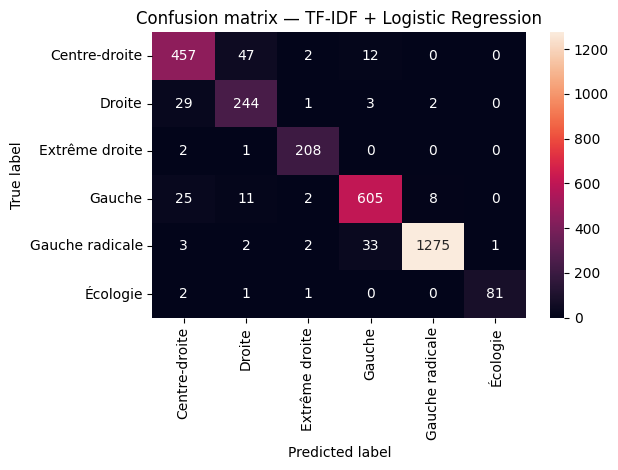

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("data/archelec_final.csv", low_memory=False)

# ── Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df["texte_ocr"],
    df["famille_politique"],
    test_size=0.2,
    random_state=42,
    stratify=df["famille_politique"]
)

# ── TF-IDF ───────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# ── Model ────────────────────────────────────────────────────
clf = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)
clf.fit(X_train_tfidf, y_train)
y_pred = clf.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion matrix — TF-IDF + Logistic Regression")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150)
plt.show()

## 4. Visualizations

### 4.1 t-SNE projection
### 4.2 Discriminative features

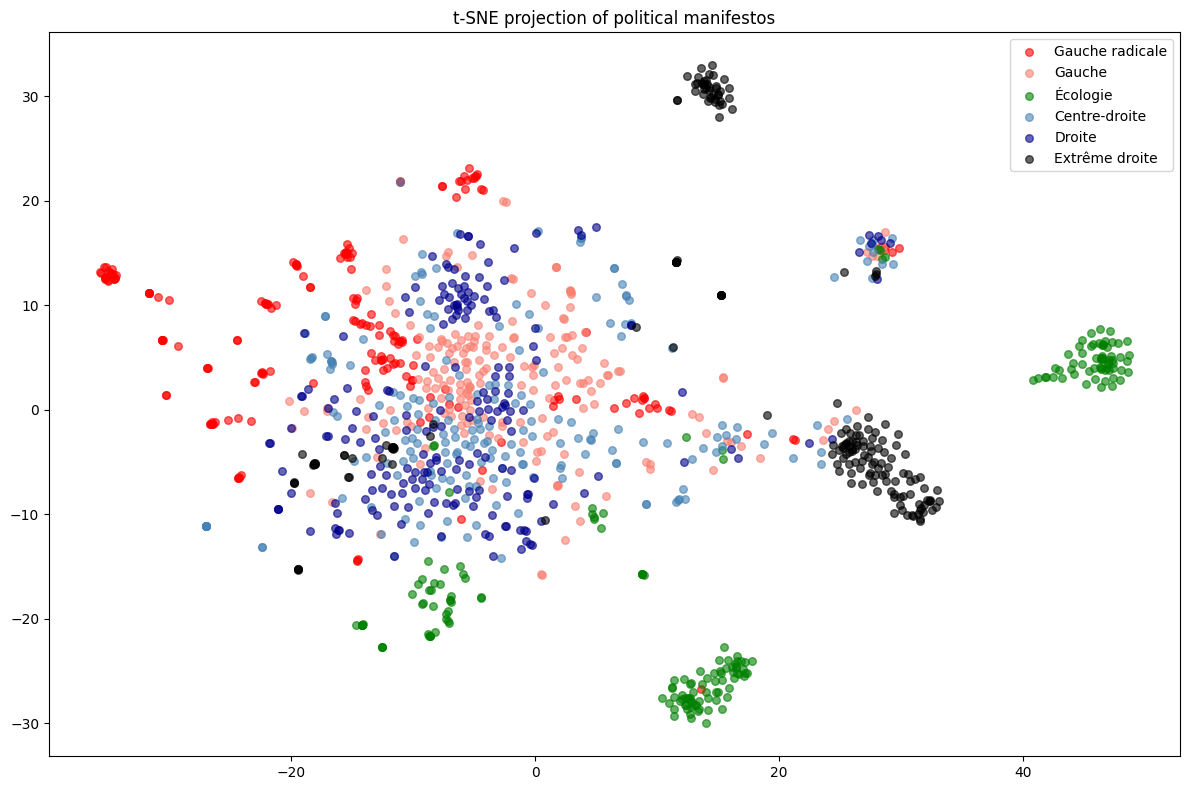

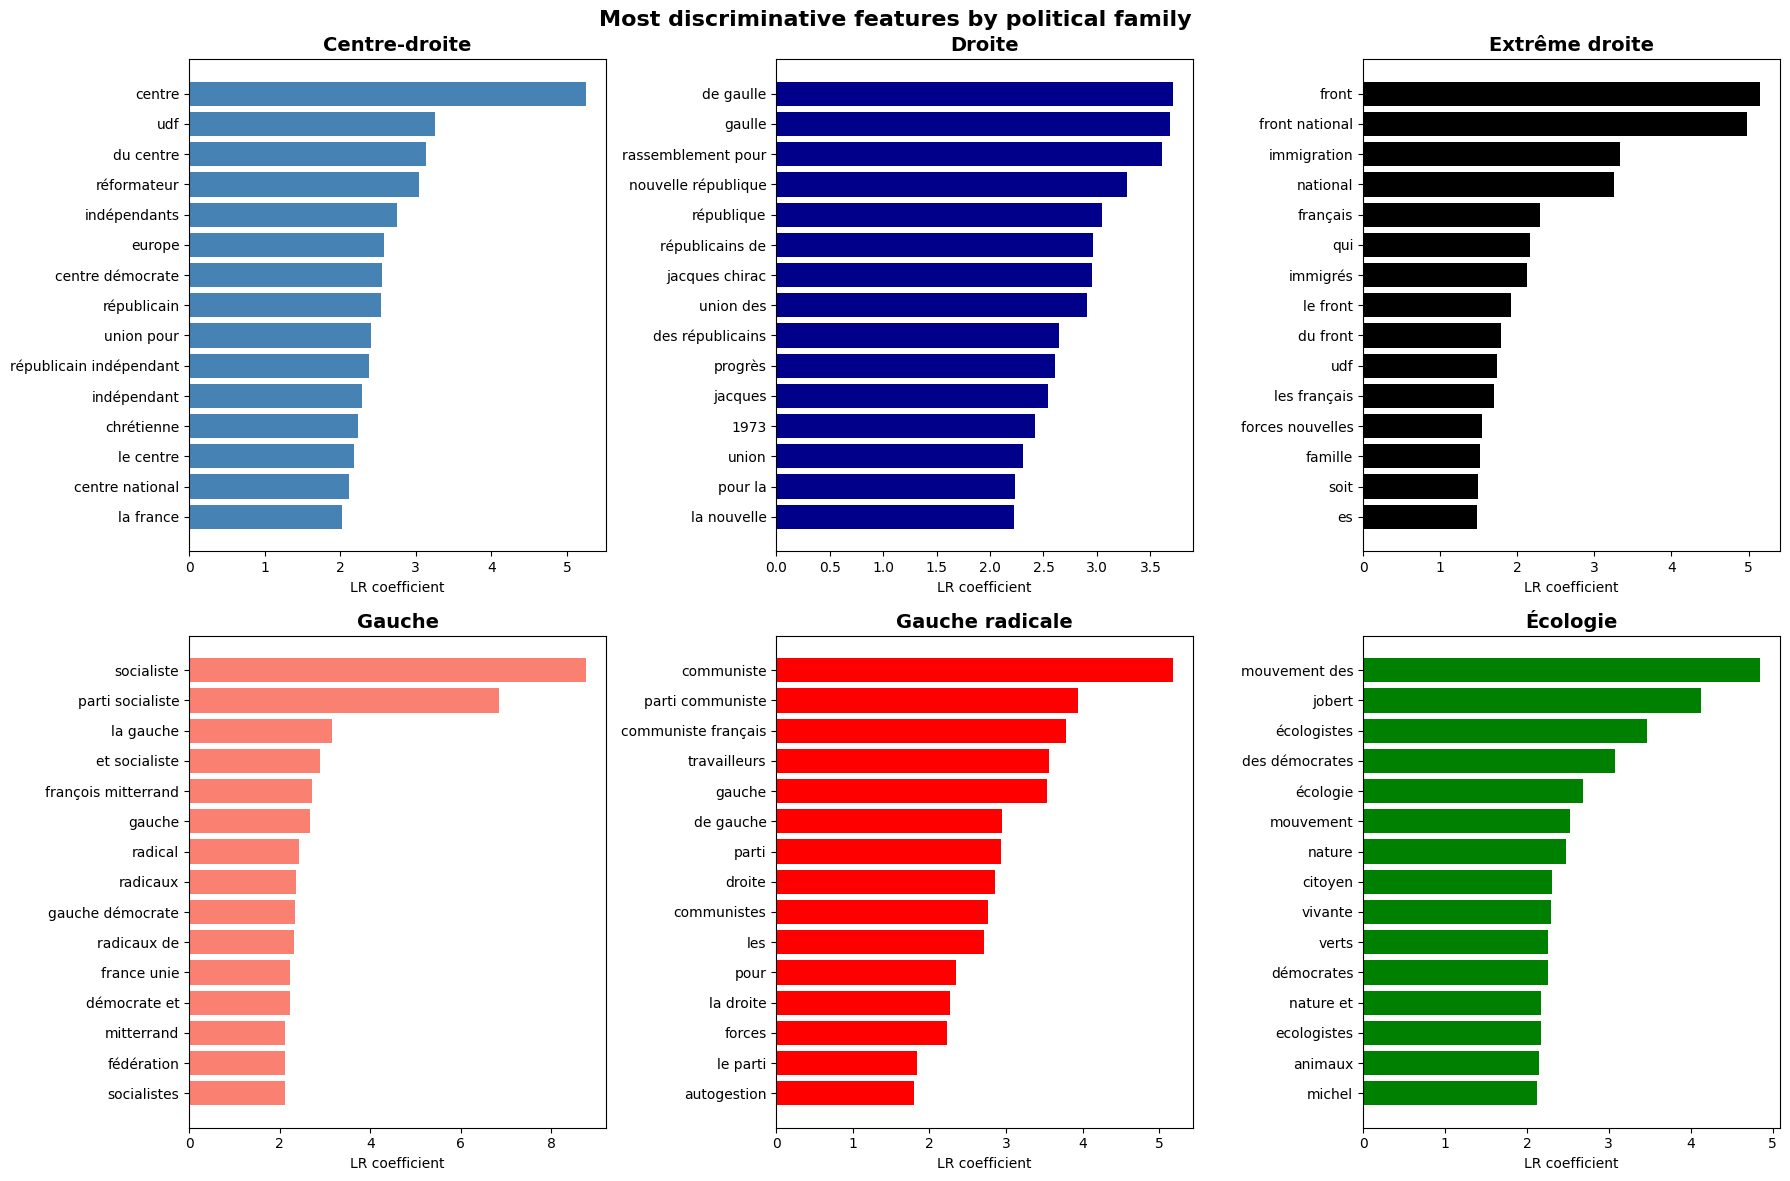

In [5]:
from sklearn.manifold import TSNE

# ── t-SNE ─────────────────────────────────────────────────────
sample = df.groupby("famille_politique").sample(n=200, random_state=42)
X_sample = tfidf.transform(sample["texte_ocr"])
y_sample = sample["famille_politique"]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_sample.toarray())

couleurs = {
    "Gauche radicale": "red",
    "Gauche": "salmon",
    "Écologie": "green",
    "Centre-droite": "steelblue",
    "Droite": "darkblue",
    "Extrême droite": "black"
}

plt.figure(figsize=(12, 8))
for famille, couleur in couleurs.items():
    mask = y_sample.values == famille
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=couleur, label=famille, alpha=0.6, s=30)
plt.legend(loc="best")
plt.title("t-SNE projection of political manifestos")
plt.tight_layout()
plt.savefig("figures/tsne_partis.png", dpi=150)
plt.show()

# ── Discriminative features ───────────────────────────────────
feature_names = tfidf.get_feature_names_out()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, classe in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[-15:][::-1]
    top_mots = feature_names[top_idx]
    top_scores = clf.coef_[i][top_idx]
    axes[i].barh(top_mots[::-1], top_scores[::-1], color=couleurs[classe])
    axes[i].set_title(classe, fontsize=14, fontweight="bold")
    axes[i].set_xlabel("LR coefficient")

plt.suptitle("Most discriminative features by political family", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/mots_discriminants.png", dpi=150)
plt.show()

## 5. Masking Experiment

Remove explicit party names and leader names to test whether models 
rely on genuine rhetorical signals or surface lexical cues.

=== TF-IDF masked ===
                 precision    recall  f1-score   support

  Centre-droite       0.81      0.74      0.77       518
         Droite       0.71      0.78      0.74       279
 Extrême droite       0.76      0.95      0.85       211
         Gauche       0.82      0.86      0.84       651
Gauche radicale       0.98      0.92      0.95      1316
       Écologie       0.78      0.86      0.82        85

       accuracy                           0.87      3060
      macro avg       0.81      0.85      0.83      3060
   weighted avg       0.87      0.87      0.87      3060



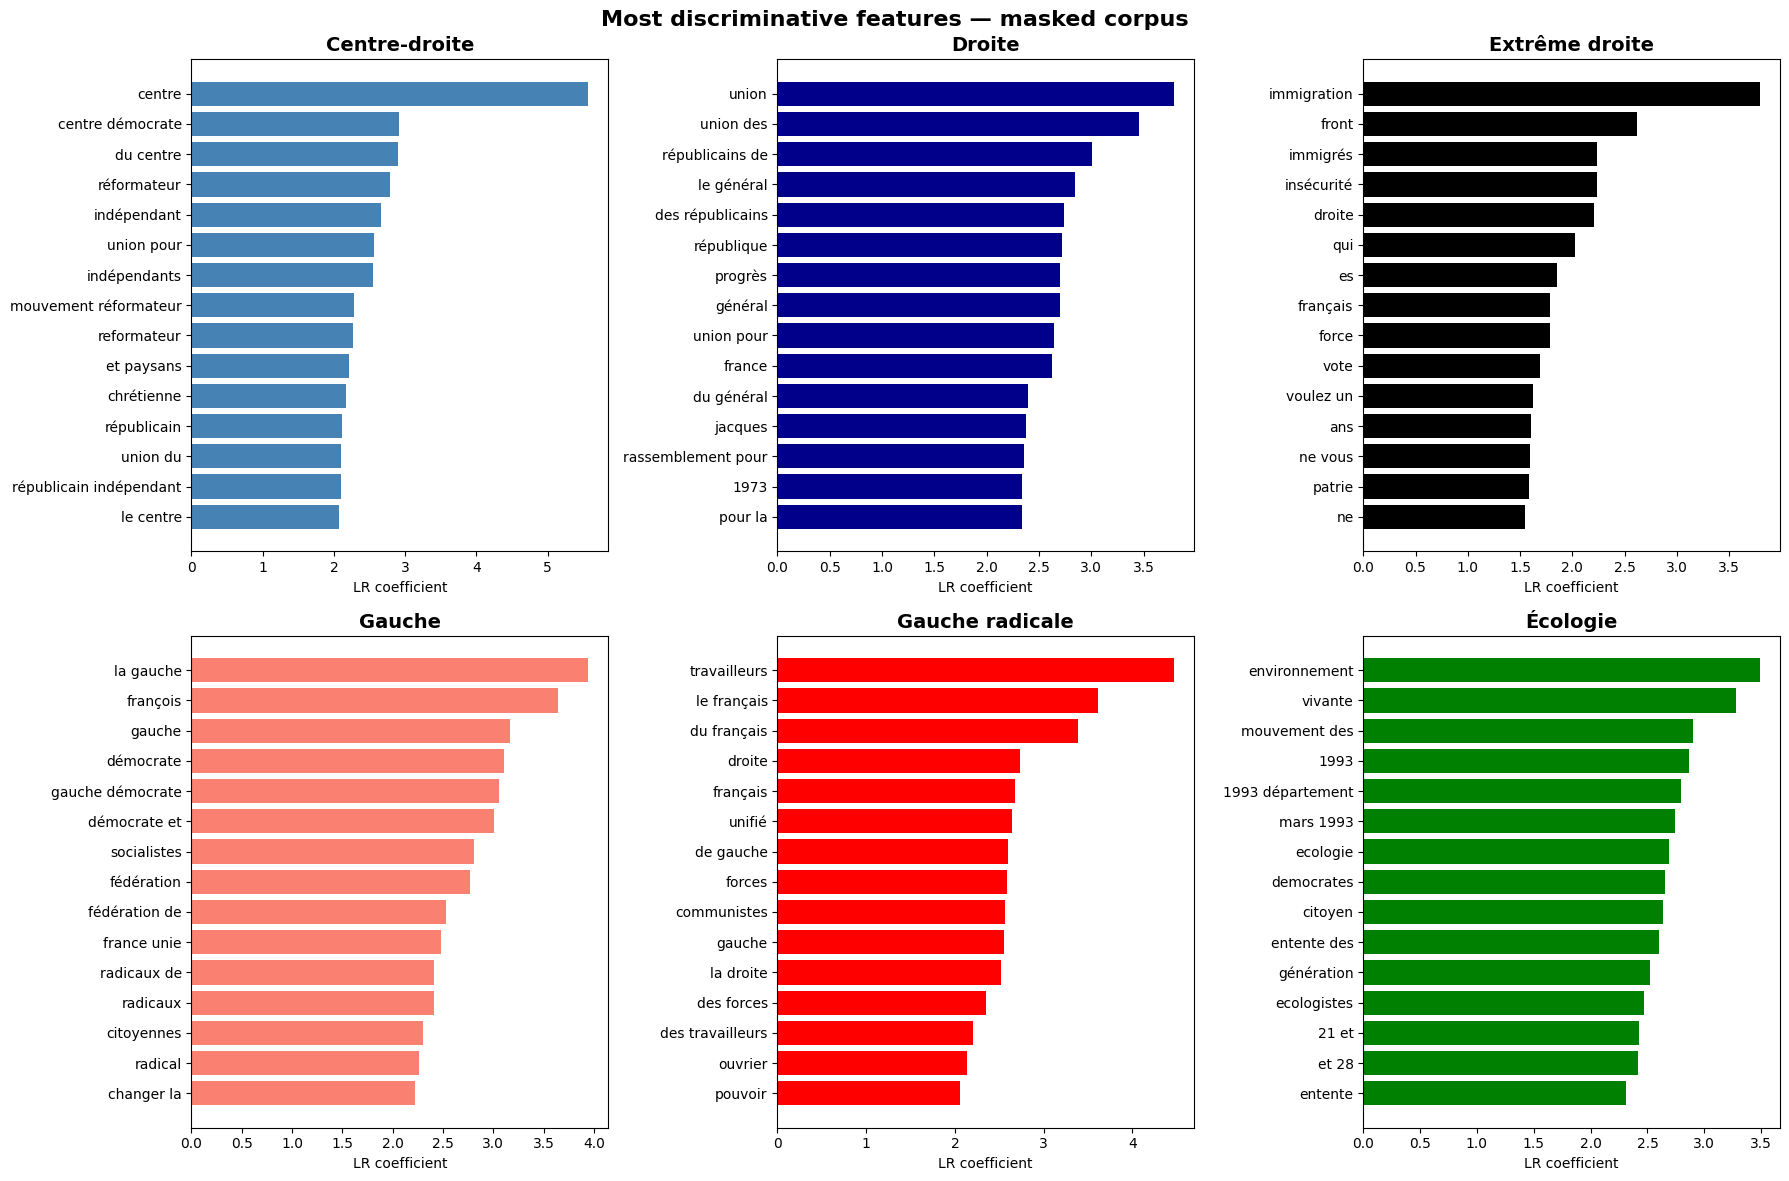

In [8]:
import re

# ── Masking ───────────────────────────────────────────────────
mots_a_masquer = [
    "parti communiste", "communiste français", "communiste", "pcf",
    "parti socialiste", "socialiste","sfio", "front national", "fn ",
    "rassemblement pour la république", "rpr",
    "union pour la démocratie française", "udf",
    "union pour la nouvelle république", "unr",
    "lutte ouvrière", "ligue communiste",
    "mouvement républicain populaire", "mrp",
    "centre national des indépendants",
    "verts", "écologie", "écologiste", "écologistes",
    "mouvement des démocrates", "forces nouvelles",
    "parti ouvrier", "mitterrand", "françois mitterrand",
    "de gaulle", "gaulle", "chirac", "jacques chirac",
    "marchais", "georges marchais", "giscard", "pompidou",
    "jospin", "rocard", "jobert", "michel jobert",
    "le pen", "jean marie le pen", "jean marie", "marie", "marie le",
    "michel", "de michel", "georges", "ségolène", "lionel",
]

def masquer_texte(texte):
    texte = texte.lower()
    for mot in mots_a_masquer:
        texte = re.sub(r'\b' + re.escape(mot) + r'\b', ' ', texte)
    return texte

df["texte_masque"] = df["texte_ocr"].str[:1500].apply(masquer_texte)

# ── TF-IDF masqué ────────────────────────────────────────────
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    df["texte_masque"],
    df["famille_politique"],
    test_size=0.2,
    random_state=42,
    stratify=df["famille_politique"]
)

tfidf_m = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
X_train_tfidf_m = tfidf_m.fit_transform(X_train_m)
X_test_tfidf_m  = tfidf_m.transform(X_test_m)

clf_m = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)
clf_m.fit(X_train_tfidf_m, y_train_m)
y_pred_m = clf_m.predict(X_test_tfidf_m)

print("=== TF-IDF masked ===")
print(classification_report(y_test_m, y_pred_m))

# ── Discriminative features masqué ───────────────────────────
feature_names_m = tfidf_m.get_feature_names_out()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, classe in enumerate(clf_m.classes_):
    top_idx = np.argsort(clf_m.coef_[i])[-15:][::-1]
    top_mots = feature_names_m[top_idx]
    top_scores = clf_m.coef_[i][top_idx]
    axes[i].barh(top_mots[::-1], top_scores[::-1], color=couleurs[classe])
    axes[i].set_title(classe, fontsize=14, fontweight="bold")
    axes[i].set_xlabel("LR coefficient")

plt.suptitle("Most discriminative features — masked corpus", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/mots_discriminants_masques.png", dpi=150)
plt.show()

## 6.1. CamemBERT Fine-tuning

> **Note**: This section requires a GPU. Run on Google Colab with T4 GPU.
> Estimated training time: ~45 minutes per experiment.

In [ ]:
# ── Install (run on Colab) ────────────────────────────────────
# !pip install transformers torch -q

from transformers import CamembertTokenizer, CamembertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Preparation ───────────────────────────────────────────────
le = LabelEncoder()
df["label"] = le.fit_transform(df["famille_politique"])
df["texte_court"] = df["texte_ocr"].str[:1500]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    df["texte_court"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")

class ManifestoDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True,
                                   max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = ManifestoDataset(X_train_c, y_train_c, tokenizer)
test_dataset  = ManifestoDataset(X_test_c,  y_test_c,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

# ── Class weights ─────────────────────────────────────────────
counts  = df["famille_politique"].value_counts()
weights = torch.tensor(
    [1.0 / counts[c] for c in le.classes_], dtype=torch.float
).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# ── Training ──────────────────────────────────────────────────
model = CamembertForSequenceClassification.from_pretrained("camembert-base", num_labels=6)
model.to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss  = loss_fn(model(**batch).logits, batch["labels"])
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ── Evaluation ────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        all_preds.extend(torch.argmax(model(**batch).logits, dim=1).cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("=== CamemBERT original ===")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

### Results (run on Google Colab T4 GPU)

**Epoch losses:**
- Epoch 1 | Loss: 0.8849
- Epoch 2 | Loss: 0.3325
- Epoch 3 | Loss: 0.2281

**Classification report:**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Centre-droite | 0.81 | 0.88 | 0.84 | 518 |
| Droite | 0.83 | 0.83 | 0.83 | 279 |
| Extrême droite | 0.80 | 0.99 | 0.89 | 211 |
| Gauche | 0.93 | 0.88 | 0.90 | 651 |
| Gauche radicale | 0.99 | 0.95 | 0.97 | 1316 |
| Écologie | 0.93 | 0.84 | 0.88 | 85 |
| **accuracy** | | | **0.91** | 3060 |

### 6.2 CamemBERT on masked corpus

In [ ]:
# ── Masking pour CamemBERT ────────────────────────────────────
df["texte_masque_court"] = df["texte_masque"].str[:1500]

X_train_cm, X_test_cm, y_train_cm, y_test_cm = train_test_split(
    df["texte_masque_court"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_dataset_m = ManifestoDataset(X_train_cm, y_train_cm, tokenizer)
test_dataset_m  = ManifestoDataset(X_test_cm,  y_test_cm,  tokenizer)

train_loader_m = DataLoader(train_dataset_m, batch_size=16, shuffle=True)
test_loader_m  = DataLoader(test_dataset_m,  batch_size=16)

# ── Training ──────────────────────────────────────────────────
model_m = CamembertForSequenceClassification.from_pretrained("camembert-base", num_labels=6)
model_m.to(device)
optimizer_m = AdamW(model_m.parameters(), lr=2e-5)

for epoch in range(3):
    model_m.train()
    total_loss = 0
    for batch in train_loader_m:
        batch = {k: v.to(device) for k, v in batch.items()}
        loss  = loss_fn(model_m(**batch).logits, batch["labels"])
        loss.backward()
        optimizer_m.step()
        optimizer_m.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader_m):.4f}")

# ── Evaluation ────────────────────────────────────────────────
model_m.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader_m:
        batch = {k: v.to(device) for k, v in batch.items()}
        all_preds.extend(torch.argmax(model_m(**batch).logits, dim=1).cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("=== CamemBERT masked ===")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

### Results — CamemBERT masked (run on Google Colab T4 GPU)

**Epoch losses:**
- Epoch 1 | Loss: 0.9974
- Epoch 2 | Loss: 0.4248
- Epoch 3 | Loss: 0.2769

**Classification report:**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Centre-droite | 0.86 | 0.80 | 0.83 | 518 |
| Droite | 0.77 | 0.83 | 0.80 | 279 |
| Extrême droite | 0.80 | 0.99 | 0.88 | 211 |
| Gauche | 0.87 | 0.86 | 0.86 | 651 |
| Gauche radicale | 0.97 | 0.96 | 0.96 | 1316 |
| Écologie | 0.95 | 0.85 | 0.89 | 85 |
| **accuracy** | | | **0.90** | 3060 |